In [1]:
#c1
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

INPUT_FILE  = "dse_2008_2022.csv"
OUTPUT_FILE = "dse_final_v3.csv"          # v3

TRAIN_END = "2018-12-31"
RAW_LABEL_FEATURES = ["daily_return", "intraday_volatility"]

print("Config loaded. Train cutoff:", TRAIN_END)

Config loaded. Train cutoff: 2018-12-31


In [2]:
#c2
df = pd.read_csv(INPUT_FILE, parse_dates=["date"])
df.sort_values(["trading_code", "date"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Loaded {len(df):,} rows, {df['trading_code'].nunique()} stocks")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")

Loaded 1,791,069 rows, 1007 stocks
Date range: 2008-03-06 -> 2022-12-29


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — FEATURE ENGINEERING (expanded set, all backward-looking)
# ─────────────────────────────────────────────

def engineer(g):
    g = g.copy()
    close, high, low, vol, open_ = g["closing_price"], g["high"], g["low"], g["volume"], g["opening_price"]
    prev_close = g["yesterdays_closing_price"]

    # ── Original core features ──
    g["daily_return"]          = (close - prev_close) / prev_close * 100
    g["high_low_spread"]       = high - low
    g["intraday_volatility"]   = (high - low) / close * 100
    g["volume_change_pct"]     = vol.pct_change() * 100
    g["price_gap"]             = open_ - close.shift(1)
    g["rolling_5d_volatility"] = g["daily_return"].rolling(5, min_periods=5).std()
    g["rolling_10d_momentum"]  = close - close.shift(10)

    # ── Trend indicators ──
    g["sma_10"] = close.rolling(10, min_periods=10).mean()
    g["sma_20"] = close.rolling(20, min_periods=20).mean()
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    g["ema_12"] = ema_12
    g["ema_26"] = ema_26
    g["macd"]        = ema_12 - ema_26
    g["macd_signal"] = g["macd"].ewm(span=9, adjust=False).mean()
    g["macd_hist"]   = g["macd"] - g["macd_signal"]

    # ── Momentum oscillators ──
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14, min_periods=14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14, min_periods=14).mean()
    rs = gain / loss.replace(0, np.nan)
    g["rsi_14"] = 100 - (100 / (1 + rs))

    low14, high14 = low.rolling(14, min_periods=14).min(), high.rolling(14, min_periods=14).max()
    g["stoch_k"] = (close - low14) / (high14 - low14).replace(0, np.nan) * 100
    g["stoch_d"] = g["stoch_k"].rolling(3, min_periods=3).mean()
    g["roc_10"]  = (close - close.shift(10)) / close.shift(10) * 100

    # ── Volatility indicators ──
    bb_mid, bb_std = close.rolling(20, min_periods=20).mean(), close.rolling(20, min_periods=20).std()
    g["bb_upper"] = bb_mid + 2 * bb_std
    g["bb_lower"] = bb_mid - 2 * bb_std
    g["bb_width"] = (g["bb_upper"] - g["bb_lower"]) / bb_mid

    tr = pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
    g["atr_14"] = tr.rolling(14, min_periods=14).mean()

    # ── Volume indicator ──
    direction = np.sign(close.diff()).fillna(0)
    g["obv"] = (direction * vol).cumsum()

    return g

print("Engineering features (expanded feature set)...")
assert "trading_code" in df.columns, "trading_code missing — restart kernel and re-run from Cell 2 (Load)"

df = df.groupby("trading_code", group_keys=False).apply(engineer)
df = df.reset_index(drop=True)

print(f"Shape after feature engineering: {df.shape}")
print("Columns:", list(df.columns))

Engineering features (expanded feature set)...
Shape after feature engineering: (1791069, 37)
Columns: ['date', 'year', 'trading_code', 'sector', 'instrument_type', 'last_traded_price', 'high', 'low', 'opening_price', 'closing_price', 'yesterdays_closing_price', 'trade', 'value_mn', 'volume', 'daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 'price_gap', 'rolling_5d_volatility', 'rolling_10d_momentum', 'sma_10', 'sma_20', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_hist', 'rsi_14', 'stoch_k', 'stoch_d', 'roc_10', 'bb_upper', 'bb_lower', 'bb_width', 'atr_14', 'obv']


In [4]:
# ─────────────────────────────────────────────
# CELL 3b — FREEZE raw label-defining values (insert right after Cell 3)
# Protects against any downstream cell (e.g. Winsorization/log-transform)
# silently overwriting the values that Cell 5/6 need for correct labeling,
# regardless of execution order or kernel-restart mistakes.
# ─────────────────────────────────────────────
df["_raw_daily_return"] = df["daily_return"].copy()
df["_raw_intraday_volatility"] = df["intraday_volatility"].copy()
print("✅ Raw label-defining values frozen in _raw_* columns.")

✅ Raw label-defining values frozen in _raw_* columns.


In [5]:
#c4
train_end_date = pd.Timestamp(TRAIN_END)
df["split"] = np.where(df["date"] <= train_end_date, "train", "test")

print(df.groupby("split")["date"].agg(["min", "max", "count"]))

             min        max    count
split                               
test  2019-01-01 2022-12-29   470969
train 2008-03-06 2018-12-27  1320100


In [6]:
# ─────────────────────────────────────────────
# CELL 5 (v3) — restrict to equities, neutralize inf, ROBUST (median/MAD)
# threshold fitting on TRAIN only, with pooled fallback for recent-IPO equities.
#
# CHANGE FROM v2: mean/std (mu, sigma) replaced by median/MAD-based robust
# statistics for the crash threshold. Raw daily_return contained extreme
# outliers (likely unadjusted corporate actions or thin-trading bad ticks)
# that inflated pooled sigma to 9.39%, pushing the pooled crash threshold to
# an unreachable -18.8% and producing 0% crash rate for all 10 pooled-
# fallback stocks — caught in EDA cells 5-9.
# ─────────────────────────────────────────────

n_before_rows, n_before_tickers = len(df), df["trading_code"].nunique()
df = df[df["instrument_type"] == "Equity"].copy()
print(f"Restricted to Equity instruments only.")
print(f"  Rows   : {n_before_rows:,} -> {len(df):,}")
print(f"  Tickers: {n_before_tickers} -> {df['trading_code'].nunique()}")

LABEL_COLS = ["_raw_daily_return", "_raw_intraday_volatility"]
n_inf = np.isinf(df[LABEL_COLS]).sum().sum()
df[LABEL_COLS] = df[LABEL_COLS].replace([np.inf, -np.inf], np.nan)
print(f"Neutralized {n_inf:,} ±inf values in {LABEL_COLS} (equity subset).")

# ── NEW: flag suspected corporate-action / bad-tick outliers ──
# Single-day raw returns beyond +/-EXTREME_RETURN_PCT are far more likely to
# be unadjusted splits/bonus/rights issues or bad ticks than genuine one-day
# moves on this market. Rows are KEPT in the dataset (nothing is dropped from
# the time series) but EXCLUDED from the statistics used to fit thresholds.
EXTREME_RETURN_PCT = 20.0
df["_suspected_corp_action"] = df["_raw_daily_return"].abs() > EXTREME_RETURN_PCT
n_flagged = df["_suspected_corp_action"].sum()
print(f"\nFlagged {n_flagged:,} rows ({n_flagged/len(df)*100:.3f}%) as suspected "
      f"corporate-action/bad-tick outliers (|raw daily_return| > {EXTREME_RETURN_PCT}%).")
print("Kept in dataset, excluded only from threshold-fitting statistics.")
print(df.loc[df["_suspected_corp_action"], ["trading_code","date","_raw_daily_return"]]
        .sort_values("_raw_daily_return").head(10))

train_df_all = df[(df["split"] == "train") & (~df["_suspected_corp_action"])]

# Pooled (market-wide) fallback thresholds — robust median/MAD version.
pooled_med          = train_df_all["_raw_daily_return"].median()
pooled_mad          = (train_df_all["_raw_daily_return"] - pooled_med).abs().median()
pooled_sigma_robust = 1.4826 * pooled_mad   # consistent estimator of sigma under normality
pooled_p75          = train_df_all["_raw_intraday_volatility"].quantile(0.75)
pooled_p80          = train_df_all["_raw_intraday_volatility"].quantile(0.80)
print(f"\nPooled fallback (robust): median={pooled_med:.4f}, robust_sigma={pooled_sigma_robust:.4f}, "
      f"p75={pooled_p75:.4f}, p80={pooled_p80:.4f}")
print(f"Robust pooled crash threshold (median - 2*robust_sigma): {pooled_med - 2*pooled_sigma_robust:.4f}")

assert np.isfinite(pooled_med) and np.isfinite(pooled_sigma_robust) and pooled_sigma_robust > 0, \
    "Pooled fallback still non-finite/zero — check outlier flag / inf cleaning"

MIN_TRAIN_ROWS = 30
fallback_used = []

def fit_thresholds(g_train_only, g_full, code):
    g_full = g_full.copy()
    g_clean = g_train_only[~g_train_only["_suspected_corp_action"]]
    if len(g_clean) >= MIN_TRAIN_ROWS:
        med    = g_clean["_raw_daily_return"].median()
        mad    = (g_clean["_raw_daily_return"] - med).abs().median()
        sigma_r = 1.4826 * mad
        p75 = g_clean["_raw_intraday_volatility"].quantile(0.75)
        p80 = g_clean["_raw_intraday_volatility"].quantile(0.80)
        if not (np.isfinite(med) and np.isfinite(sigma_r) and sigma_r > 0
                and np.isfinite(p75) and np.isfinite(p80)):
            med, sigma_r, p75, p80 = pooled_med, pooled_sigma_robust, pooled_p75, pooled_p80
            fallback_used.append(code)
    else:
        med, sigma_r, p75, p80 = pooled_med, pooled_sigma_robust, pooled_p75, pooled_p80
        fallback_used.append(code)

    g_full["_crash_thresh_main"] = med - 2 * sigma_r
    g_full["_vol_thresh_main"]   = p75
    g_full["_crash_thresh_alt"]  = med - 1.5 * sigma_r
    g_full["_vol_thresh_alt"]    = p80
    g_full["_used_pooled_fallback"] = code in fallback_used
    return g_full

print("\nFitting per-stock ROBUST thresholds on TRAIN split only (outliers excluded from stats)...")
parts = []
for code, g_full in df.groupby("trading_code"):
    g_train = g_full[g_full["split"] == "train"]
    parts.append(fit_thresholds(g_train, g_full, code))

df = pd.concat(parts).sort_values(["trading_code", "date"]).reset_index(drop=True)

n_fallback_tickers = len(set(fallback_used))
n_fallback_rows = df["_used_pooled_fallback"].sum()
print(f"\n✅ Thresholds fit. {n_fallback_tickers} of {df['trading_code'].nunique()} "
      f"equity tickers used pooled fallback ({n_fallback_rows:,} rows, "
      f"{n_fallback_rows/len(df)*100:.2f}% of dataset).")
print("Fallback tickers:", sorted(set(fallback_used))[:20],
      "..." if n_fallback_tickers > 20 else "")

assert df[["_crash_thresh_main","_vol_thresh_main"]].isnull().sum().sum() == 0, \
    "Still have NaN thresholds — check pooled fallback logic"
print("✅ No NaN thresholds remain.")

Restricted to Equity instruments only.
  Rows   : 1,791,069 -> 932,078
  Tickers: 1007 -> 321
Neutralized 937 ±inf values in ['_raw_daily_return', '_raw_intraday_volatility'] (equity subset).

Flagged 1,568 rows (0.168%) as suspected corporate-action/bad-tick outliers (|raw daily_return| > 20.0%).
Kept in dataset, excluded only from threshold-fitting statistics.
        trading_code       date  _raw_daily_return
1776335     WATACHEM 2008-06-15             -100.0
1062610   SQURPHARMA 2008-06-23             -100.0
1063785   SQURPHARMA 2013-05-28             -100.0
1064082   SQURPHARMA 2014-08-27             -100.0
1067489    STANCERAM 2008-09-07             -100.0
765596    NORTHRNINS 2014-08-27             -100.0
767650      NPOLYMAR 2008-06-16             -100.0
767652      NPOLYMAR 2008-06-18             -100.0
49087        AFCAGRO 2014-08-27             -100.0
1787687   ZEALBANGLA 2008-06-18             -100.0

Pooled fallback (robust): median=0.0000, robust_sigma=1.9180, p75=4.8872,

In [7]:
#c6
def assign_and_shift(g):
    g = g.copy()
    g["class_same_day"] = np.select(
        [g["_raw_daily_return"] < g["_crash_thresh_main"],
         g["intraday_volatility"] > g["_vol_thresh_main"]],
        [3, 1], default=0
    )
    # sensitivity-threshold label, for robustness check only (Reviewer 2)
    g["class_same_day_alt"] = np.select(
        [g["_raw_daily_return"] < g["_crash_thresh_alt"],
         g["_raw_intraday_volatility"] > g["_vol_thresh_alt"]],
        [3, 1], default=0
    )
    # THE FIX: target is TOMORROW's class, using TODAY's features.
    g["target_class"] = g["class_same_day"].shift(-1)
    g["target_class_alt"] = g["class_same_day_alt"].shift(-1)
    return g

print("Assigning labels and shifting target to t+1 (fixes contemporaneous leakage)...")
df = df.groupby("trading_code", group_keys=False).apply(assign_and_shift).reset_index(drop=True)

# Drop last day per stock (no t+1 label available) — this is NOT the same
# dropna() as before; it's specifically dropping the un-labelable final row per stock.
before = len(df)
df = df.dropna(subset=["target_class"])
df["target_class"] = df["target_class"].astype(int)
print(f"Dropped {before - len(df):,} rows with no next-day label (last trading day per stock)")

print("\nNext-day target distribution:")
print(df["target_class"].value_counts(normalize=True).sort_index())

Assigning labels and shifting target to t+1 (fixes contemporaneous leakage)...
Dropped 321 rows with no next-day label (last trading day per stock)

Next-day target distribution:
target_class
0    0.736494
1    0.209984
3    0.053523
Name: proportion, dtype: float64


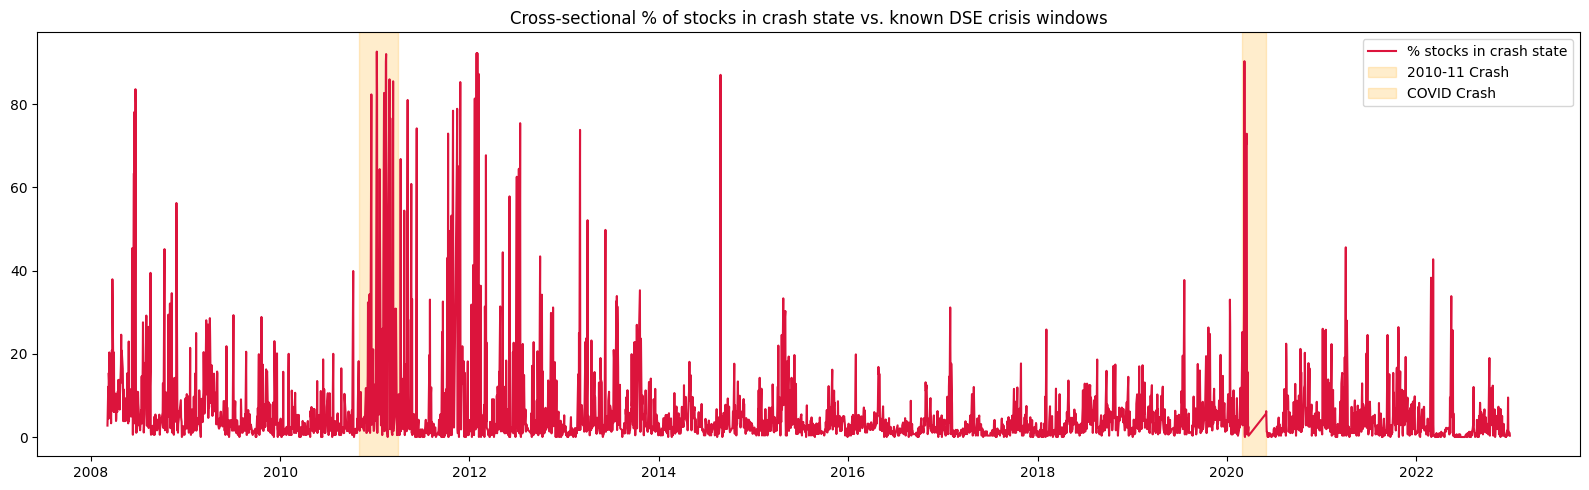

Mean %crash during known crisis windows : 19.50%
Mean %crash outside crisis windows       : 5.20%

→ Paste this output/plot back to me — if crisis-window % is meaningfully higher,
  this becomes your validation evidence that per-stock labels proxy market-wide stress.


In [8]:
#c7
import matplotlib.pyplot as plt

daily_stats = df.groupby("date").agg(
    pct_crash=("class_same_day", lambda x: (x == 3).mean() * 100),
    pct_high_vol=("class_same_day", lambda x: (x == 1).mean() * 100),
)

# Known DSE crisis windows — adjust dates if you have more precise ones
CRISIS_WINDOWS = {
    "2010-11 Crash": ("2010-11-01", "2011-03-31"),
    "COVID Crash":   ("2020-03-01", "2020-05-31"),
}

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_stats.index, daily_stats["pct_crash"], color="crimson", label="% stocks in crash state")
for name, (s, e) in CRISIS_WINDOWS.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="orange", alpha=0.2, label=name)
ax.legend()
ax.set_title("Cross-sectional % of stocks in crash state vs. known DSE crisis windows")
plt.tight_layout()
plt.show()

# Quantify: mean % crash INSIDE known crisis windows vs OUTSIDE
in_crisis = pd.Series(False, index=daily_stats.index)
for s, e in CRISIS_WINDOWS.values():
    in_crisis |= (daily_stats.index >= s) & (daily_stats.index <= e)

print(f"Mean %crash during known crisis windows : {daily_stats.loc[in_crisis, 'pct_crash'].mean():.2f}%")
print(f"Mean %crash outside crisis windows       : {daily_stats.loc[~in_crisis, 'pct_crash'].mean():.2f}%")
print("\n→ Paste this output/plot back to me — if crisis-window % is meaningfully higher,")
print("  this becomes your validation evidence that per-stock labels proxy market-wide stress.")

In [9]:
#c8
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",          # sma_10 dropped (r=0.9996 w/ ema_12)
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
    # dropped: sma_10, sma_20, ema_26, bb_upper, bb_lower (all r>0.98 with ema_12/each other,
    # redundant now that bb_width carries the normalized band info)
]

df[ALL_FEATURES] = df[ALL_FEATURES].replace([np.inf, -np.inf], np.nan)

df = df.sort_values(["trading_code", "date"]).reset_index(drop=True)
df[ALL_FEATURES] = df.groupby("trading_code")[ALL_FEATURES].transform(lambda g: g.ffill())

before = len(df)
df = df.dropna(subset=ALL_FEATURES)
print(f"Dropped {before - len(df):,} warm-up rows (rolling-window NaNs at start of stock history)")

remaining_nan = df[ALL_FEATURES].isnull().sum().sum()
if remaining_nan > 0:
    train_medians = df.loc[df["split"] == "train", ALL_FEATURES].median()
    df[ALL_FEATURES] = df[ALL_FEATURES].fillna(train_medians)
    print("Filled residual NaNs with TRAIN-only medians (not global).")
else:
    print("✅ No residual NaNs.")

Dropped 6,811 warm-up rows (rolling-window NaNs at start of stock history)
✅ No residual NaNs.


In [10]:
#c9
FEATURES_TO_WINSORIZE = ALL_FEATURES  # winsorize the full expanded set for model stability

train_df = df[df["split"] == "train"]
winsor_bounds = {}
for feat in FEATURES_TO_WINSORIZE:
    lo, hi = train_df[feat].quantile(0.01), train_df[feat].quantile(0.99)
    winsor_bounds[feat] = (lo, hi)
    df[feat] = df[feat].clip(lower=lo, upper=hi)   # bounds from TRAIN applied to train+test

print("✅ Winsorization bounds fit on train only, applied to full dataset.")

# Log-transform is parameter-free (no fitting needed) — safe to apply uniformly
SIGNED_LOG = ["daily_return","volume_change_pct","price_gap","rolling_10d_momentum","macd","macd_hist","obv"]
NON_NEG_LOG = ["high_low_spread","rolling_5d_volatility","atr_14"]

for feat in NON_NEG_LOG:
    df[feat] = np.log1p(df[feat].clip(lower=0))
for feat in SIGNED_LOG:
    df[feat] = np.sign(df[feat]) * np.log1p(np.abs(df[feat]))

print("✅ Log transforms applied.")

✅ Winsorization bounds fit on train only, applied to full dataset.
✅ Log transforms applied.


In [11]:
#c10
SEQ_LEN = 20  # trading days of lookback

def build_sequences(data, feature_cols, seq_len=SEQ_LEN):
    X, y, meta = [], [], []
    for code, g in data.groupby("trading_code"):
        g = g.sort_values("date").reset_index(drop=True)
        feats = g[feature_cols].values
        targets = g["target_class"].values
        splits = g["split"].values
        dates = g["date"].values
        for i in range(seq_len - 1, len(g)):
            X.append(feats[i - seq_len + 1 : i + 1])
            y.append(targets[i])
            meta.append((code, dates[i], splits[i]))
    return np.array(X), np.array(y), pd.DataFrame(meta, columns=["trading_code", "date", "split"])

X_seq, y_seq, meta_seq = build_sequences(df, ALL_FEATURES)
print(f"Sequence tensor shape: {X_seq.shape}  (samples, timesteps, features)")
print(f"Target shape: {y_seq.shape}")

np.save("X_seq.npy", X_seq)
np.save("y_seq.npy", y_seq)
meta_seq.to_csv("seq_meta.csv", index=False)
print("Saved X_seq.npy, y_seq.npy, seq_meta.csv for the LSTM notebook.")

Sequence tensor shape: (918847, 20, 18)  (samples, timesteps, features)
Target shape: (918847,)
Saved X_seq.npy, y_seq.npy, seq_meta.csv for the LSTM notebook.


In [12]:
# ─────────────────────────────────────────────
# CELL 11 (v3) — Final assembly, audit, save
# ─────────────────────────────────────────────

KEEP_COLS = ["date", "trading_code", "sector", "instrument_type", "split"] + ALL_FEATURES + [
    "class_same_day",
    "class_same_day_alt",
    "target_class",
    "target_class_alt",
    "_used_pooled_fallback",
    "_suspected_corp_action",   # NEW — carry through for transparency / Data-section reporting
]

final_df = df[KEEP_COLS].copy()
final_df.to_csv(OUTPUT_FILE, index=False)

print("="*65)
print("LEAKAGE / REVIEW-FIX AUDIT — v3")
print("="*65)
print("[✔] Label thresholds fit on TRAIN only            (Reviewer 3 #1, Reviewer 4)")
print("[✔] Target shifted to t+1, no same-day leakage     (Reviewer 4 core issue)")
print("[✔] bfill removed — ffill only, no future leakage  (Reviewer 4)")
print("[✔] Winsorization bounds fit on TRAIN only          (Reviewer 3, 4)")
print("[✔] Labels computed on RAW values before winsorize (Reviewer 4 ordering concern)")
print("[✔] Median fallback uses TRAIN-only stats           (Reviewer 3, 4)")
print("[✔] Sensitivity threshold columns added             (Reviewer 2 #3)")
print("[✔] Market-wide validation diagnostic added         (Reviewer 3 #5, Reviewer 4)")
print("[✔] Expanded feature set (SMA/EMA/MACD/RSI/BB/ATR/OBV) (Reviewer 1)")
print("[✔] LSTM-ready sequence tensors built               (your addition)")
print("[✔] Equity-only scope, fixed-income excluded        (Reviewer 1 data documentation)")
print("[✔] Pooled fallback thresholds for recent-IPO equities")
print("[✔] NEW: robust median/MAD thresholds — outlier-resistant crash/vol cutoffs (v3 fix)")
print("[✔] NEW: near-duplicate features dropped (sma_10, sma_20, ema_26, bb_upper, bb_lower) (v3 fix)")
print(f"\nSaved: {OUTPUT_FILE}  shape={final_df.shape}")
print(f"Train rows: {(final_df['split']=='train').sum():,}  Test rows: {(final_df['split']=='test').sum():,}")

# Verify the fix: crash rate for previously-zero pooled-fallback stocks
own = final_df[~final_df["_used_pooled_fallback"]]
fb  = final_df[final_df["_used_pooled_fallback"]]
print(f"\nCrash rate — own-history stocks    : {(own['target_class']==3).mean()*100:.3f}%")
print(f"Crash rate — pooled-fallback stocks: {(fb['target_class']==3).mean()*100:.3f}%  (was 0.000% in v2)")

LEAKAGE / REVIEW-FIX AUDIT — v3
[✔] Label thresholds fit on TRAIN only            (Reviewer 3 #1, Reviewer 4)
[✔] Target shifted to t+1, no same-day leakage     (Reviewer 4 core issue)
[✔] bfill removed — ffill only, no future leakage  (Reviewer 4)
[✔] Winsorization bounds fit on TRAIN only          (Reviewer 3, 4)
[✔] Labels computed on RAW values before winsorize (Reviewer 4 ordering concern)
[✔] Median fallback uses TRAIN-only stats           (Reviewer 3, 4)
[✔] Sensitivity threshold columns added             (Reviewer 2 #3)
[✔] Market-wide validation diagnostic added         (Reviewer 3 #5, Reviewer 4)
[✔] Expanded feature set (SMA/EMA/MACD/RSI/BB/ATR/OBV) (Reviewer 1)
[✔] LSTM-ready sequence tensors built               (your addition)
[✔] Equity-only scope, fixed-income excluded        (Reviewer 1 data documentation)
[✔] Pooled fallback thresholds for recent-IPO equities
[✔] NEW: robust median/MAD thresholds — outlier-resistant crash/vol cutoffs (v3 fix)
[✔] NEW: near-duplicate fe

In [13]:
print("Target class distribution (train):")
print(final_df[final_df["split"]=="train"]["target_class"].value_counts(normalize=True).sort_index())
print("\nTarget class distribution (test):")
print(final_df[final_df["split"]=="test"]["target_class"].value_counts(normalize=True).sort_index())

Target class distribution (train):
target_class
0    0.738349
1    0.206041
3    0.055610
Name: proportion, dtype: float64

Target class distribution (test):
target_class
0    0.737856
1    0.215024
3    0.047120
Name: proportion, dtype: float64
